In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [2]:
PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")

DATASET_PATH = (
    PROJECT_PATH
    / "datasets"
)

VIDEO_FEATURE_PATH = (
    DATASET_PATH
    / "processed"
    / "video_features"
)

print(VIDEO_FEATURE_PATH)

/content/drive/MyDrive/UAH_Project/datasets/processed/video_features


In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
video_feature_files = sorted(
    VIDEO_FEATURE_PATH.glob("*.npy")
)

print("Video feature count:", len(video_feature_files))

for f in video_feature_files[:5]:
    print(f.name)

Video feature count: 40
20151110175712-16km-D1-NORMAL1-SECONDARY.npy
20151110180846-16km-D1-NORMAL2-SECONDARY.npy
20151111123123-25km-D1-NORMAL-MOTORWAY.npy
20151111125204-24km-D1-AGGRESSIVE-MOTORWAY.npy
20151111132343-25km-D1-DROWSY-MOTORWAY.npy


In [5]:
sample_feature = np.load(video_feature_files[0])

print(sample_feature.shape)

(606, 2048)


In [6]:
print(sample_feature[0].shape)

print(sample_feature[0][:20])

(2048,)
[0.00035145 0.00329909 0.00865296 0.         0.03819646 0.
 0.01856839 0.17746009 0.02749926 0.00057345 0.00813574 0.01040255
 0.09256989 0.00032695 0.02175526 0.21325858 0.01501497 0.02746757
 0.         0.00195527]


In [7]:
SENSOR_DATASET_PATH = (
    PROJECT_PATH
    / "datasets"
    / "processed"
    / "uah_dataset.npz"
)

sensor_data = np.load(SENSOR_DATASET_PATH)

X = sensor_data["X"]
y = sensor_data["y"]
groups = sensor_data["groups"]

print(X.shape)
print(y.shape)
print(groups.shape)

(30676, 120, 13)
(30676,)
(30676,)


In [8]:
print(np.unique(groups))
print(len(np.unique(groups)))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
40


In [9]:
for trip_id in range(5):

    count = np.sum(groups == trip_id)

    print(
        f"Trip {trip_id}: {count} sensor sequences"
    )

Trip 0: 606 sensor sequences
Trip 1: 641 sensor sequences
Trip 2: 855 sensor sequences
Trip 3: 717 sensor sequences
Trip 4: 930 sensor sequences


In [10]:
for i in range(5):

    feature = np.load(video_feature_files[i])

    print(
        f"Trip {i}: {feature.shape}"
    )

Trip 0: (606, 2048)
Trip 1: (641, 2048)
Trip 2: (855, 2048)
Trip 3: (717, 2048)
Trip 4: (930, 2048)


In [11]:
sensor_samples = []
video_samples = []
labels = []

for trip_id in range(40):

    sensor_trip = X[groups == trip_id]

    video_trip = np.load(
        video_feature_files[trip_id]
    )

    label_trip = y[groups == trip_id]

    sensor_samples.append(sensor_trip)
    video_samples.append(video_trip)
    labels.append(label_trip)

In [12]:
print(len(sensor_samples))
print(len(video_samples))
print(len(labels))

40
40
40


In [13]:
print(sensor_samples[0].shape)
print(video_samples[0].shape)
print(labels[0].shape)

(606, 120, 13)
(606, 2048)
(606,)


In [14]:
sensor_samples = np.concatenate(
    sensor_samples,
    axis=0,
)

video_samples = np.concatenate(
    video_samples,
    axis=0,
)

labels = np.concatenate(
    labels,
    axis=0,
)

In [15]:
print(sensor_samples.shape)
print(video_samples.shape)
print(labels.shape)

(30676, 120, 13)
(30568, 2048)
(30676,)


In [16]:
sample_id = 0

print(sensor_samples[sample_id].shape)
print(video_samples[sample_id].shape)
print(labels[sample_id])

(120, 13)
(2048,)
0


In [17]:
for trip_id in range(40):

    sensor_count = np.sum(groups == trip_id)

    video_count = np.load(
        video_feature_files[trip_id]
    ).shape[0]

    if sensor_count != video_count:

        print(
            f"Trip {trip_id}: "
            f"Sensor={sensor_count} "
            f"Video={video_count}"
        )

Trip 19: Sensor=651 Video=555
Trip 24: Sensor=676 Video=664


In [18]:
sensor_samples = []
video_samples = []
labels = []

for trip_id in range(40):

    sensor_trip = X[groups == trip_id]

    video_trip = np.load(
        video_feature_files[trip_id]
    )

    label_trip = y[groups == trip_id]

    # Ortak uzunluk
    common_length = min(
        len(sensor_trip),
        len(video_trip),
    )

    sensor_samples.append(
        sensor_trip[:common_length]
    )

    video_samples.append(
        video_trip[:common_length]
    )

    labels.append(
        label_trip[:common_length]
    )

In [19]:
sensor_samples = np.concatenate(sensor_samples)

video_samples = np.concatenate(video_samples)

labels = np.concatenate(labels)

In [20]:
print(sensor_samples.shape)
print(video_samples.shape)
print(labels.shape)

(30568, 120, 13)
(30568, 2048)
(30568,)


In [21]:
class MultimodalDataset(Dataset):

    def __init__(
        self,
        sensor_data,
        video_data,
        labels,
    ):

        self.sensor_data = torch.FloatTensor(sensor_data)
        self.video_data = torch.FloatTensor(video_data)
        self.labels = torch.LongTensor(labels)

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return (
            self.sensor_data[idx],
            self.video_data[idx],
            self.labels[idx],
        )

In [22]:
dataset = MultimodalDataset(
    sensor_samples,
    video_samples,
    labels,
)

print(len(dataset))

30568


In [23]:
sensor, video, label = dataset[0]

print(sensor.shape)
print(video.shape)
print(label)

torch.Size([120, 13])
torch.Size([2048])
tensor(0)


In [24]:
sensor_samples = []
video_samples = []
labels = []
aligned_groups = []

for trip_id in range(40):

    sensor_trip = X[groups == trip_id]

    video_trip = np.load(
        video_feature_files[trip_id]
    )

    label_trip = y[groups == trip_id]

    common_length = min(
        len(sensor_trip),
        len(video_trip),
    )

    sensor_samples.append(
        sensor_trip[:common_length]
    )

    video_samples.append(
        video_trip[:common_length]
    )

    labels.append(
        label_trip[:common_length]
    )

    aligned_groups.append(
        np.full(common_length, trip_id)
    )

In [25]:
sensor_samples = np.concatenate(sensor_samples)
video_samples = np.concatenate(video_samples)
labels = np.concatenate(labels)
aligned_groups = np.concatenate(aligned_groups)

In [26]:
print(sensor_samples.shape)
print(video_samples.shape)
print(labels.shape)
print(aligned_groups.shape)

(30568, 120, 13)
(30568, 2048)
(30568,)
(30568,)


In [27]:
from sklearn.model_selection import train_test_split

unique_groups = np.unique(aligned_groups)

train_groups, test_groups = train_test_split(
    unique_groups,
    test_size=0.20,
    random_state=42,
)

train_mask = np.isin(
    aligned_groups,
    train_groups,
)

test_mask = np.isin(
    aligned_groups,
    test_groups,
)

print("Train trips:", train_groups)
print("Test trips :", test_groups)

Train trips: [39  6 25  9 13 31 34  8 17 24  0 33  5 11  1 29 21  2 30 36  3 35 23 32
 10 22 18 20  7 14 28 38]
Test trips : [19 16 15 26  4 12 37 27]


In [28]:
X_sensor_train = sensor_samples[train_mask]
X_sensor_test = sensor_samples[test_mask]

X_video_train = video_samples[train_mask]
X_video_test = video_samples[test_mask]

y_train = labels[train_mask]
y_test = labels[test_mask]

In [29]:
print(X_sensor_train.shape)
print(X_video_train.shape)
print(y_train.shape)

print()

print(X_sensor_test.shape)
print(X_video_test.shape)
print(y_test.shape)

(24103, 120, 13)
(24103, 2048)
(24103,)

(6465, 120, 13)
(6465, 2048)
(6465,)


In [34]:
import sys

sys.path.append("/content/drive/MyDrive/UAH_Project/src")

In [35]:
import importlib

import fusion_model

importlib.reload(fusion_model)

from fusion_model import MultimodalFusion

In [36]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = MultimodalFusion().to(device)

print(model)

MultimodalFusion(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (video_encoder): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=320, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [37]:
train_dataset = MultimodalDataset(
    X_sensor_train,
    X_video_train,
    y_train,
)

test_dataset = MultimodalDataset(
    X_sensor_test,
    X_video_test,
    y_test,
)

print(len(train_dataset))
print(len(test_dataset))

24103
6465


In [38]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

print(len(train_loader))
print(len(test_loader))

754
203


In [39]:
sensor, video, label = next(iter(train_loader))

print(sensor.shape)
print(video.shape)
print(label.shape)

torch.Size([32, 120, 13])
torch.Size([32, 2048])
torch.Size([32])


In [58]:
import sys

sys.path.append("/content/drive/MyDrive/UAH_Project/src")

In [64]:
import os
os.chdir("/content/drive/MyDrive/UAH_Project")

In [65]:
import sys

SRC = "/content/drive/MyDrive/UAH_Project/src"

if SRC not in sys.path:
    sys.path.insert(0, SRC)

import importlib
importlib.invalidate_caches()

import fusion_trainer

importlib.reload(fusion_trainer)

from fusion_trainer import fit

In [66]:
import importlib

import fusion_trainer

importlib.reload(fusion_trainer)

from fusion_trainer import fit

In [67]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)

print(class_weights)

[0.69645747 1.28714087 1.27025033]


In [68]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = MultimodalFusion().to(device)

In [69]:
weights = torch.FloatTensor(class_weights).to(device)

criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

In [70]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

In [71]:
EPOCHS = 20
PATIENCE = 3

In [72]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
)

Epoch 1/20 | Train Loss: 0.6501 | Train Acc: 0.6962 | Val Loss: 1.8131 | Val Acc: 0.3176
Epoch 2/20 | Train Loss: 0.2652 | Train Acc: 0.8919 | Val Loss: 2.7561 | Val Acc: 0.2704
Epoch 3/20 | Train Loss: 0.1465 | Train Acc: 0.9472 | Val Loss: 3.0794 | Val Acc: 0.2911
Epoch 4/20 | Train Loss: 0.0854 | Train Acc: 0.9712 | Val Loss: 3.8753 | Val Acc: 0.2540

Early stopping at epoch 4
Best Validation Accuracy: 0.3176


In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for sensor, video, labels in test_loader:

        sensor = sensor.to(device)
        video = video.to(device)

        outputs = model(sensor, video)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [74]:
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")

print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")

print(f"Recall   : {recall_score(y_true, y_pred, average='weighted'):.4f}")

print(f"F1 Score : {f1_score(y_true, y_pred, average='weighted'):.4f}")

Accuracy : 0.3176
Precision: 0.5950
Recall   : 0.3176
F1 Score : 0.3296


In [75]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.16      0.33      0.22      1455
      DROWSY       0.90      0.22      0.35      3496
  AGGRESSIVE       0.31      0.54      0.40      1514

    accuracy                           0.32      6465
   macro avg       0.46      0.36      0.32      6465
weighted avg       0.59      0.32      0.33      6465



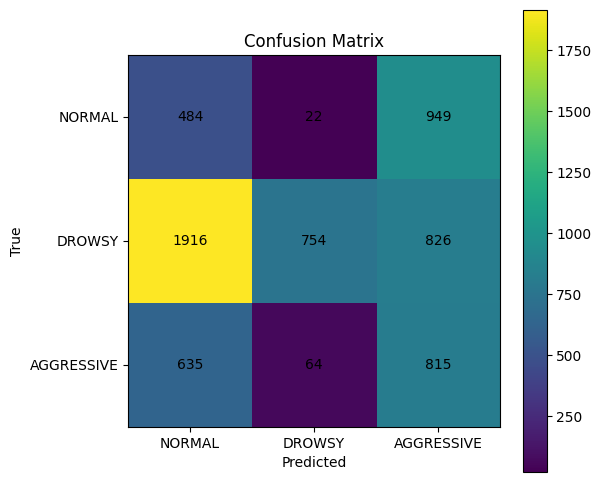

In [76]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.xlabel("Predicted")

plt.ylabel("True")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
        )

plt.show()